In [11]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

files = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc"
]

In [6]:
# =========================
# CLEAN ML PIPELINE (FINAL VERSION)
# =========================

import h5py
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# =========================
# CONFIG
# =========================
FILES = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc"
]

PREDICTORS = ["TREFHT", "QBOT", "PRECT", "PRSN", "FLNS", "FSNS", "UBOT", "VBOT"]
TARGET = "TREFMXAV_U"

MAN_LAT = 53.4808
MAN_LON = -2.2426

# =========================
# FUNCTIONS
# =========================
def get_nearest_idx(lat_arr, lon_arr, target_lat, target_lon):
    lon_arr_180 = ((lon_arr + 180) % 360) - 180
    lat_idx = np.argmin(np.abs(lat_arr - target_lat))
    lon_idx = np.argmin(np.abs(lon_arr_180 - target_lon))
    return lat_idx, lon_idx


def build_dates_noleap():
    dates = []
    for year in range(2006, 2081):
        for month in range(1, 13):
            days = [31,28,31,30,31,30,31,31,30,31,30,31][month-1]
            for day in range(1, days+1):
                dates.append(pd.Timestamp(year, month, day))
    return pd.Series(dates[1:])


def load_data(file):
    with h5py.File(file, 'r') as f:
        lat = f['lat'][:]
        lon = f['lon'][:]
        lat_idx, lon_idx = get_nearest_idx(lat, lon, MAN_LAT, MAN_LON)

        data = {}
        for v in PREDICTORS + [TARGET]:
            arr = f[v][:, lat_idx, lon_idx].astype(float)
            arr[arr > 1e30] = np.nan
            data[v] = arr

    df = pd.DataFrame(data)

    df['TREFHT'] -= 273.15
    df['TREFMXAV_U'] -= 273.15

    df['Date'] = build_dates_noleap().values
    df['Year'] = df['Date'].dt.year
    df['DOY'] = df['Date'].dt.dayofyear
    df['sin_doy'] = np.sin(2*np.pi*df['DOY']/365)
    df['cos_doy'] = np.cos(2*np.pi*df['DOY']/365)

    return df

# =========================
# LOAD DATA
# =========================
all_df = []
for f in FILES:
    df = load_data(f)
    all_df.append(df)

df = pd.concat(all_df).dropna()

# =========================
# FEATURES
# =========================
features = PREDICTORS + ['Year', 'sin_doy', 'cos_doy']
X = df[features]
y = df[TARGET]

# =========================
# SPLIT
# =========================
train = df[df.Year <= 2044]
val   = df[(df.Year >= 2045) & (df.Year <= 2049)]
test  = df[df.Year >= 2050]

X_train, y_train = train[features], train[TARGET]
X_val, y_val     = val[features], val[TARGET]
X_test, y_test   = test[features], test[TARGET]

# =========================
# MODELS
# =========================
models = {
    "RF": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    "XGB": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    "LGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, verbosity=-1, random_state=42),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(C=10, epsilon=0.1))
    ]),
    "SVR_PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("svr", SVR(C=10, epsilon=0.1))
    ])
}

# =========================
# TRAIN & EVALUATE
# =========================
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results.append([name, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])
print("\nFINAL RESULTS (2050-2080):")
print(results_df.sort_values("RMSE"))

# =========================
# FEATURE IMPORTANCE (RF)
# =========================
rf = models["RF"]
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (RF):")
print(feat_imp)


Training RF...
Training XGB...
Training LGBM...
Training SVR...
Training SVR_PCA...

FINAL RESULTS (2050-2080):
     Model      RMSE       MAE        R2
1      XGB  0.688772  0.506621  0.983764
2     LGBM  0.697645  0.513658  0.983343
0       RF  0.717128  0.540502  0.982400
3      SVR  1.597890  1.068845  0.912619
4  SVR_PCA  1.693763  1.178420  0.901819

Feature Importance (RF):
    Feature    Importance
0    TREFHT  9.462457e-01
4      FLNS  3.978221e-02
5      FSNS  3.681991e-03
6      UBOT  3.560041e-03
1      QBOT  2.277512e-03
7      VBOT  1.947611e-03
9   sin_doy  1.245024e-03
10  cos_doy  9.242289e-04
8      Year  3.257128e-04
2     PRECT  9.693565e-06
3      PRSN  3.151846e-07


Number of PCA components to explain 90% variance: 7
Training SVR (Original)...
Training SVR (PCA)...
                    RMSE        R2
SVR (Original)  0.705767  0.982262
SVR (PCA)       0.956653  0.967410


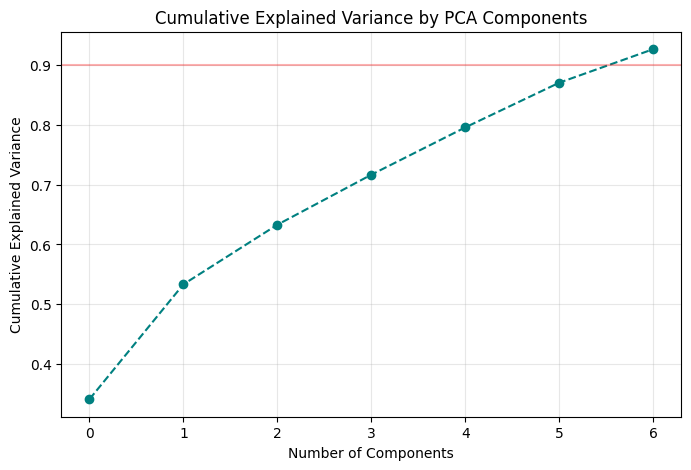

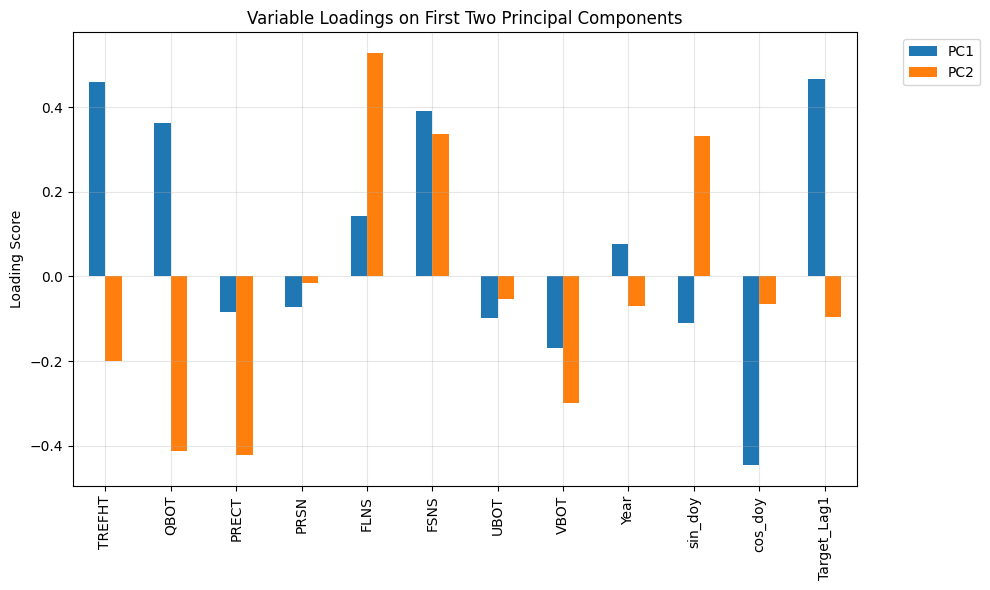

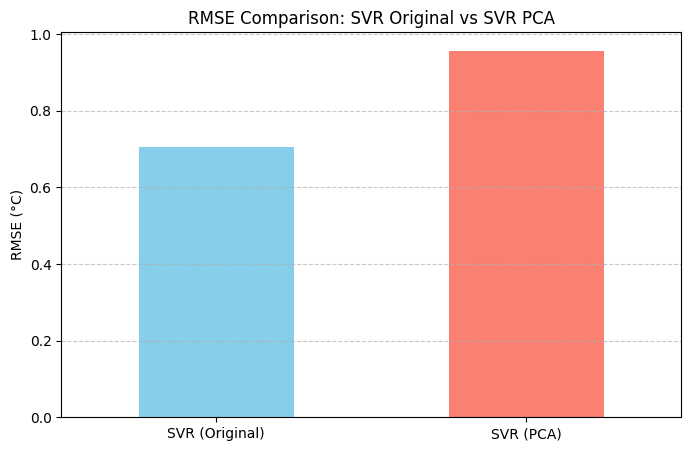

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load data for Manchester (lat=5, lon=3)
files = ["003_2006_2080_352_360.nc", "004_2006_2080_352_360.nc", 
         "005_2006_2080_352_360.nc", "006_2006_2080_352_360.nc", 
         "007_2006_2080_352_360.nc", "008_2006_2080_352_360.nc"]

def load_manchester_data(filename):
    with h5py.File(filename, 'r') as f:
        vars_to_load = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'TREFMXAV_U']
        data_dict = {}
        lat_idx, lon_idx = 5, 3
        for v in vars_to_load:
            d = f[v][:]
            d[d > 1e30] = np.nan
            data_dict[v] = d[:, lat_idx, lon_idx]
        
        df = pd.DataFrame(data_dict)
        df['TREFHT'] -= 273.15
        df['TREFMXAV_U'] -= 273.15
        
        n_days = len(df)
        df['DayOfYear'] = (np.arange(n_days) % 365) + 1
        df['Year'] = 2006 + (np.arange(n_days) // 365)
        df['sin_doy'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
        df['cos_doy'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        return df.dropna().reset_index(drop=True)

# 2. Ensemble Split
train_dfs = [load_manchester_data(f) for f in files[:-1]]
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_manchester_data(files[-1])

features = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 
            'Year', 'sin_doy', 'cos_doy', 'Target_Lag1']
X_train, y_train = df_train[features], df_train['TREFMXAV_U']
X_test, y_test = df_test[features], df_test['TREFMXAV_U']

# 3. PCA Implementation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#保留90%的方差信息
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

n_components = pca.n_components_
print(f"Number of PCA components to explain 90% variance: {n_components}")

# 4. Modeling & Comparison
# Model A: SVR on Original Scaled Features
print("Training SVR (Original)...")
svr_orig = SVR(kernel='rbf', C=10, epsilon=0.1)
# Use a smaller subset for faster training in this demo env if needed, 
# but we'll try full training as we have 136k samples. 
# Actually, SVR on 136k can be slow. Let's sample 15k for the SVR comparison.
indices = np.random.choice(len(X_train_scaled), 15000, replace=False)
svr_orig.fit(X_train_scaled[indices], y_train.iloc[indices])
y_pred_orig = svr_orig.predict(X_test_scaled)

# Model B: SVR on PCA Features
print("Training SVR (PCA)...")
svr_pca = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_pca.fit(X_train_pca[indices], y_train.iloc[indices])
y_pred_pca = svr_pca.predict(X_test_pca)

# 5. Visualizations
# Plot 1: Cumulative Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='teal')
plt.axhline(y=0.9, color='red', linestyle='-', alpha=0.3)
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True, alpha=0.3)
plt.savefig("pca_variance_plot.png")

# Plot 2: Variable Loadings on PC1 & PC2
# This shows which physical variables dominate the principal components
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(n_components)], index=features)
plt.figure(figsize=(10, 6))
loadings[['PC1', 'PC2']].plot(kind='bar', ax=plt.gca())
plt.title("Variable Loadings on First Two Principal Components")
plt.ylabel("Loading Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_loadings_plot.png")

# Plot 3: Metrics Comparison
metrics = {
    'SVR (Original)': [np.sqrt(mean_squared_error(y_test, y_pred_orig)), r2_score(y_test, y_pred_orig)],
    'SVR (PCA)': [np.sqrt(mean_squared_error(y_test, y_pred_pca)), r2_score(y_test, y_pred_pca)]
}
df_metrics = pd.DataFrame(metrics, index=['RMSE', 'R2']).T
df_metrics.to_csv("pca_model_comparison.csv")

plt.figure(figsize=(8, 5))
df_metrics['RMSE'].plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("RMSE Comparison: SVR Original vs SVR PCA")
plt.ylabel("RMSE (°C)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("pca_metrics_comparison.png")

print(df_metrics)

Loading data...
Training Models...
Generating Master Dashboard...


/var/folders/z_/cgsk2pf150570djfzwp929fc0000gn/T/ipykernel_11383/4179341805.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


success 'manchester_master_dashboard.png'


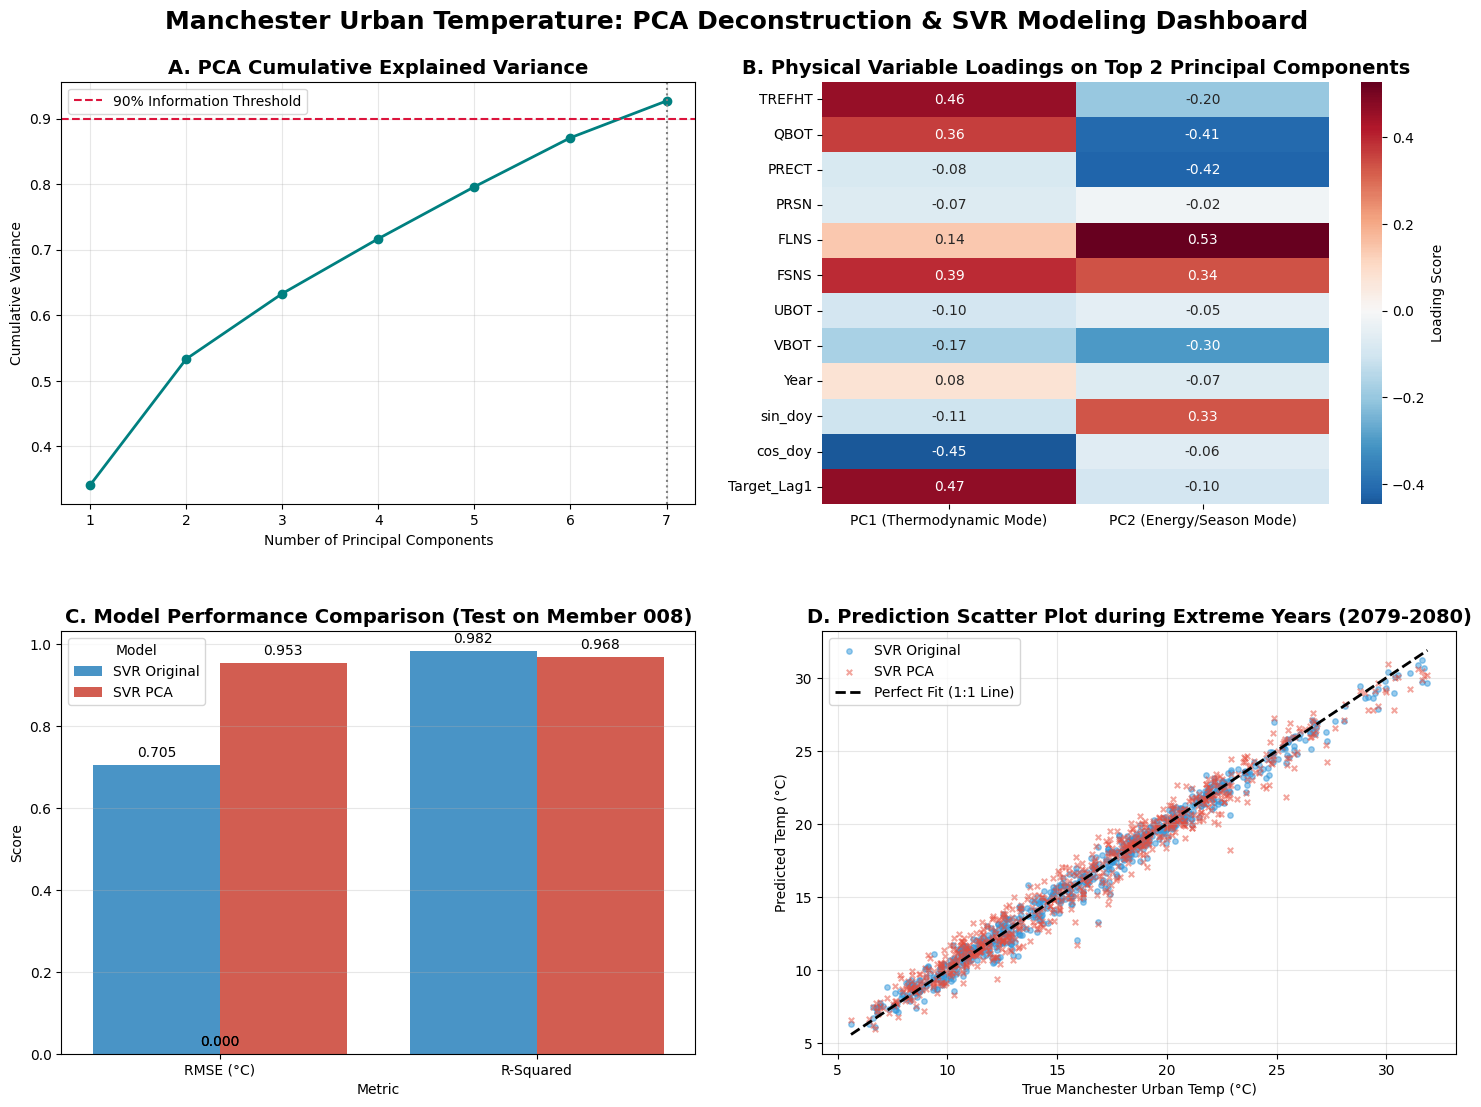

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

files = ["003_2006_2080_352_360.nc", "004_2006_2080_352_360.nc", 
         "005_2006_2080_352_360.nc", "006_2006_2080_352_360.nc", 
         "007_2006_2080_352_360.nc", "008_2006_2080_352_360.nc"]

def load_manchester_data(filename):
    with h5py.File(filename, 'r') as f:
        vars_to_load = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'TREFMXAV_U']
        lat_idx, lon_idx = 5, 3
        data_dict = {}
        for v in vars_to_load:
            d = f[v][:]
            d[d > 1e30] = np.nan
            data_dict[v] = d[:, lat_idx, lon_idx]
        
        df = pd.DataFrame(data_dict)
        df['TREFHT'] -= 273.15
        df['TREFMXAV_U'] -= 273.15
        
        df['sin_doy'] = np.sin(2 * np.pi * (np.arange(len(df)) % 365 + 1) / 365)
        df['cos_doy'] = np.cos(2 * np.pi * (np.arange(len(df)) % 365 + 1) / 365)
        df['Year'] = 2006 + (np.arange(len(df)) // 365)
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        return df.dropna().reset_index(drop=True)

print("Loading data...")
train_dfs = [load_manchester_data(f) for f in files[:-1]]
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_manchester_data(files[-1])

features = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'Year', 'sin_doy', 'cos_doy', 'Target_Lag1']
X_train, y_train = df_train[features], df_train['TREFMXAV_U']
X_test, y_test = df_test[features], df_test['TREFMXAV_U']

# ==========================================
# 2. PCA
# ==========================================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

pca = PCA(n_components=0.90) 
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

np.random.seed(42)
idx = np.random.choice(len(X_train_sc), 15000, replace=False)

print("Training Models...")
svr_orig = SVR(kernel='rbf', C=10, epsilon=0.1).fit(X_train_sc[idx], y_train.iloc[idx])
svr_pca = SVR(kernel='rbf', C=10, epsilon=0.1).fit(X_train_pca[idx], y_train.iloc[idx])

y_pred_orig = svr_orig.predict(X_test_sc)
y_pred_pca = svr_pca.predict(X_test_pca)

rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
r2_orig = r2_score(y_test, y_pred_orig)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))
r2_pca = r2_score(y_test, y_pred_pca)

# ==========================================
# 3. Master Dashboard
# ==========================================
print("Generating Master Dashboard...")
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.2)

# ---  A  ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         np.cumsum(pca.explained_variance_ratio_), 'teal', marker='o', linestyle='-', linewidth=2)
ax1.axhline(0.9, color='crimson', linestyle='--', label='90% Information Threshold')
ax1.axvline(pca.n_components_, color='gray', linestyle=':')
ax1.set_title("A. PCA Cumulative Explained Variance", fontsize=14, fontweight='bold')
ax1.set_xlabel("Number of Principal Components")
ax1.set_ylabel("Cumulative Variance")
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- B  ---
ax2 = fig.add_subplot(gs[0, 1])
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1 (Thermodynamic Mode)', 'PC2 (Energy/Season Mode)'], index=features)
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax2, cbar_kws={'label': 'Loading Score'})
ax2.set_title("B. Physical Variable Loadings on Top 2 Principal Components", fontsize=14, fontweight='bold')

# ---  C  ---
ax3 = fig.add_subplot(gs[1, 0])
metrics_df = pd.DataFrame({
    'Metric': ['RMSE (°C)', 'RMSE (°C)', 'R-Squared', 'R-Squared'],
    'Model': ['SVR Original', 'SVR PCA', 'SVR Original', 'SVR PCA'],
    'Value': [rmse_orig, rmse_pca, r2_orig, r2_pca]
})
sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_df, ax=ax3, palette=['#3498db', '#e74c3c'])
for p in ax3.patches:
    ax3.annotate(format(p.get_height(), '.3f'), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
ax3.set_title("C. Model Performance Comparison (Test on Member 008)", fontsize=14, fontweight='bold')
ax3.set_ylabel("Score")
ax3.grid(axis='y', alpha=0.3)

# --- D  ---
ax4 = fig.add_subplot(gs[1, 1])
mask = df_test['Year'] >= 2079
ax4.scatter(y_test[mask], y_pred_orig[mask], alpha=0.5, color='#3498db', label='SVR Original', s=15)
ax4.scatter(y_test[mask], y_pred_pca[mask], alpha=0.5, color='#e74c3c', label='SVR PCA', marker='x', s=15)
min_val = min(y_test[mask].min(), y_pred_orig[mask].min())
max_val = max(y_test[mask].max(), y_pred_orig[mask].max())
ax4.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Fit (1:1 Line)')
ax4.set_title("D. Prediction Scatter Plot during Extreme Years (2079-2080)", fontsize=14, fontweight='bold')
ax4.set_xlabel("True Manchester Urban Temp (°C)")
ax4.set_ylabel("Predicted Temp (°C)")
ax4.legend()
ax4.grid(True, alpha=0.3)

# save
plt.suptitle("Manchester Urban Temperature: PCA Deconstruction & SVR Modeling Dashboard", fontsize=18, fontweight='heavy', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92) 
plt.savefig("manchester_master_dashboard.png", dpi=300, bbox_inches='tight')
print("success 'manchester_master_dashboard.png'")